In [1]:
import pandas as pd
import os
import joblib
import torch
import sys
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
import pyBumpHunter as BH
import seaborn as sns
from scipy.interpolate import griddata
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from scipy.stats import norm
from scipy.stats import chi2
from matplotlib import gridspec
import pickle
import pyhf

hep.style.use(hep.style.ROOT)

helpers_path = os.path.join('/home/aegis/aslan/NRAD_Project/NRAD_OpenData/model_scripts')
sys.path.insert(0, os.path.abspath(helpers_path))
from Classifier import Classifier

/home/aegis/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## SETTINGS and LOADING EVENTS

In [2]:
selection = "ATLAS"
LUMI = 25.3845 # fb^-1
N_GEN_SIG = 100_000

SIGNAL_DIR = "/home/aegis/aslan/NRAD_Project/NRAD_Signal/Analysis_Output_ver2"
SCALER_PATH = f"Final_Dataset_{selection}/minmax_scaler.joblib"
MODELS_DIR = f"Eval_CWoLa_SR_{selection}_ver2/"
model_path = f"Models_Extrapolation_{selection}_ver2"

METADATA_LIST = [
    {"Mass": 1000, "Rinv": 2, "XS": 9551.0, "TheoryUnc": 0.52},
    {"Mass": 1000, "Rinv": 4, "XS": 9540.0, "TheoryUnc": 0.52},
    {"Mass": 1000, "Rinv": 6, "XS": 9552.0, "TheoryUnc": 0.52},
    {"Mass": 1000, "Rinv": 8, "XS": 9554.0, "TheoryUnc": 0.52},
    {"Mass": 2000, "Rinv": 2, "XS": 146.3, "TheoryUnc": 0.53},
    {"Mass": 2000, "Rinv": 4, "XS": 146.8, "TheoryUnc": 0.53},
    {"Mass": 2000, "Rinv": 6, "XS": 146.1, "TheoryUnc": 0.53},
    {"Mass": 2000, "Rinv": 8, "XS": 145.3, "TheoryUnc": 0.53},
    {"Mass": 3000, "Rinv": 2, "XS": 14.24, "TheoryUnc": 0.48},
    {"Mass": 3000, "Rinv": 4, "XS": 14.20, "TheoryUnc": 0.48},
    {"Mass": 3000, "Rinv": 6, "XS": 14.21, "TheoryUnc": 0.48},
    {"Mass": 3000, "Rinv": 8, "XS": 14.26, "TheoryUnc": 0.48},
]
DF_META = pd.DataFrame(METADATA_LIST)

DEVICE = "cpu"
N_ENSEMBLE = 10
context_vars = ['met_recalc_pt', 'ht']
features_vars = ['ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32', 'mjj']

scaler = joblib.load(SCALER_PATH)
device = torch.device("cpu")

SIGNAL_MODES = ["1000_2", "1000_4", "1000_6", "1000_8", "2000_2", "2000_4", "2000_6", "2000_8", "3000_2", "3000_4", "3000_6", "3000_8"]

In [3]:
def load_signal(mode_str, detector_mode,  base_path=SIGNAL_DIR):

    file_path = os.path.join(base_path, "SR", f"bsm_{mode_str}_{detector_mode}.parquet")
    if not os.path.exists(file_path):
        print(f"Error: Signal file {file_path} not found.")
        return None

    sig_pre_cols = [
        "tau21_j1", "tau32_j1", "tau21_j2", "tau32_j2", 
        "ht", "met_recalc_pt", "mjj"
    ]
    df_sim = pd.read_parquet(file_path, columns=sig_pre_cols)
    row = DF_META[(DF_META['Mass'] == int(mode_str.split("_")[0])) & (DF_META['Rinv'] == int(mode_str.split("_")[1]))]
    xs_eff, theory_unc = row.iloc[0]['XS'], row.iloc[0]['TheoryUnc']
    norm_factor = (xs_eff * LUMI) / N_GEN_SIG

    df_sim['weight'] = norm_factor
    
    rename_mapping = {
        "m_jj": "mjj",
        "tau21_j1": "ljet1_tau21",
        "tau32_j1": "ljet1_tau32",
        "tau21_j2": "ljet2_tau21",
        "tau32_j2": "ljet2_tau32",
        "met": "met_recalc_pt",
        "weight": "final_weight"
    }
    df_sim = df_sim.rename(columns=rename_mapping)
    
    return df_sim


In [4]:
def apply_sr_cuts(df):
    return df[
        (df["ht"] > 600) & 
        (df["met_recalc_pt"] > 600) & 
        (df["met_recalc_pt"] < 2000) & 
        (df["mjj"] < 10000) & 
        (df["ht"] < 4000)
    ]

def transform(df, scale=True):
    # 1. Create a copy immediately so the original remains untouched
    df_transformed = df.copy()
    
    # Order of the variables 
    features_to_scale = [
        'met_recalc_pt', 'ht', 
        'mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32'
    ]

    # 2. Apply transformations to the COPY
    if scale:
        df_transformed.loc[:, features_to_scale] = scaler.transform(df_transformed[features_to_scale].values).astype('float32')
    else:
        df_transformed.loc[:, features_to_scale] = scaler.inverse_transform(df_transformed[features_to_scale].values).astype('float32')
        
    # 3. Return the modified copy
    return df_transformed

def score_BSM(df, bkg_type, k = 5):
    features_vars = ['ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32', 'mjj']

    sig_events_to_score = df[features_vars].values

    all_scores = []
    for i in range(k):
        model_name = f"model_Data_vs_{bkg_type}_ATLAS_fold{i + 1}.pt"
        NN = torch.load(f"{MODELS_DIR}/kfold/{model_name}", map_location=DEVICE, weights_only=False)
        NN.model.eval()

        scores_sig = NN.evaluation(sig_events_to_score).flatten()
        all_scores.append(scores_sig)

    df[f"bsm_score_{bkg_type}"] = np.median(all_scores, axis = 0)
    return df


def process_bsm_signal(sig_id, mode):
    """Loads and processes a single signal dataset."""
    df = load_signal(sig_id, mode)
    df = apply_sr_cuts(df)
    df = transform(df)
    df = score_BSM(df, "Nom")
    df = score_BSM(df, "Reweight_Median")
    df = score_BSM(df, "Generate_Combined")
    return df

In [5]:
# Load SR Data and Background (Nomnial, Reweight, and Generate)

df_data = pd.read_parquet(f"{MODELS_DIR}/scored_datasets/DATA_SR_scored.parquet")
df_mc_rw = pd.read_parquet(f"{MODELS_DIR}/scored_datasets/MC_SR_reweighted_scored.parquet")
nominal_w = df_mc_rw["final_weight"].values
rw_ensemble_weights = [df_mc_rw[f'reweight_weights_ens{i}'].values for i in range(N_ENSEMBLE)]
rw_median = np.median(rw_ensemble_weights, axis=0)
df_mc_rw["rw_mediam_weights"] = nominal_w * rw_median

gen_dfs = []
for i in range(N_ENSEMBLE):
    # Note: enumerate started at 0 in your saving script, so it's ens0 to ens4
    df = pd.read_parquet(f"{MODELS_DIR}/scored_datasets/MC_SR_Generate_ens{i}_scored.parquet")
    
    # Scale the weights directly in the dataframe
    df['total_weight'] = df['total_weight'] / 10
    
    gen_dfs.append(df)
df_mc_gen = pd.concat(gen_dfs, ignore_index=True)

# Invert Scores since I mistakenly trained data to be 0 and background to be 1, but I want the opposite. So, I will invert the scores here.
df_data['score_vs_nominal'] = 1.0 - df_data['score_vs_nominal']
df_data['score_vs_reweighted'] = 1.0 - df_data['score_vs_reweighted']
df_data['score_vs_generate'] = 1.0 - df_data['score_vs_generate']

df_mc_rw['score_vs_data'] = 1.0 - df_mc_rw['score_vs_data']
df_mc_rw['score_vs_reweighted_data'] = 1.0 - df_mc_rw['score_vs_reweighted_data']

df_mc_gen['score_vs_data'] = 1.0 - df_mc_gen['score_vs_data']

In [6]:
detector_modes = ["default", "pu", "run2", "pu_run2"]
sig_dfs = {mode: {} for mode in detector_modes}

for mode in detector_modes:
    for sig_id in SIGNAL_MODES:
        # This runs your pipeline and stores it perfectly organized
        sig_dfs[mode][sig_id] = process_bsm_signal(sig_id, mode)

detector_type = "default" # default, pu, run2, pu_run2
df_sig_def = sig_dfs[detector_type]

# Invert Scores for Signal DataFrames
for sig_id in SIGNAL_MODES:
    df_sig_def[sig_id]['bsm_score_Nom'] = 1.0 - df_sig_def[sig_id]['bsm_score_Nom']
    df_sig_def[sig_id]['bsm_score_Reweight_Median'] = 1.0 - df_sig_def[sig_id]['bsm_score_Reweight_Median']
    df_sig_def[sig_id]['bsm_score_Generate_Combined'] = 1.0 - df_sig_def[sig_id]['bsm_score_Generate_Combined']

In [7]:
# Unscale back to physical values for analysis
df_data_unscaled = transform(df_data, scale=False)
df_mc_rw_unscaled = transform(df_mc_rw, scale=False)
df_mc_gen_unscaled = transform(df_mc_gen, scale=False)

df_sig_def_unscaled = {}

for sig_id in SIGNAL_MODES:
    df_sig_def_unscaled[sig_id] = transform(df_sig_def[sig_id], scale=False)

In [8]:
# Background Efficiency
# [0.20, 0.10, 0.05, 0.03, 0.02, 0.01, 0.005, 0.001]
bkg_eff = 0.001

## Phase 1 (Background Only)

In [9]:
def apply_hybrid_cut(df_data, df_bkg, bkg_type, target_eff=0.01):
    """
    Finds the NN score threshold for the top X% of background and cuts both datasets.
    Uses predefined column configurations based on bkg_type ('NOM', 'RW', or 'GEN').
    """
    
    # 1. Map column names based on background type
    if bkg_type == "NOM":
        data_score_col = "score_vs_nominal"
        bkg_score_col = "score_vs_data"
        weight_col = "final_weight"
    elif bkg_type == "RW":
        data_score_col = "score_vs_reweighted"
        bkg_score_col = "score_vs_reweighted_data"
        weight_col = "rw_mediam_weights"
    elif bkg_type == "GEN":
        data_score_col = "score_vs_generate"
        bkg_score_col = "score_vs_data"
        weight_col = "total_weight"
    else:
        raise ValueError("bkg_type must be 'NOM', 'RW', or 'GEN'")

    # 2. Extract scores and weights
    bkg_scores = df_bkg[bkg_score_col].values
    bkg_weights = df_bkg[weight_col].values

    # 3. Sort to find the exact threshold based on weights
    sort_idx = np.argsort(bkg_scores)
    sorted_scores = bkg_scores[sort_idx]
    sorted_weights = np.abs(bkg_weights[sort_idx])
    
    cum_weights = np.cumsum(sorted_weights)
    if cum_weights[-1] == 0:
        raise ValueError("Total background weight is zero. Cannot compute threshold.")
        
    cum_weights_norm = cum_weights / cum_weights[-1]

    # 4. Find threshold for the target efficiency
    threshold_idx = np.searchsorted(cum_weights_norm, 1.0 - target_eff)
    
    # Protect against out-of-bounds index
    if threshold_idx >= len(sorted_scores):
        threshold_idx = len(sorted_scores) - 1
        
    threshold = sorted_scores[threshold_idx]
    
    print(f"--- {bkg_type} Cut ---")
    print(f"Applying cut at NN Score > {threshold:.4f} (Top {target_eff*100:.1f}% Background)")

    # 5. Filter and return new datasets
    data_sr = df_data[df_data[data_score_col] > threshold].copy()
    bkg_sr = df_bkg[df_bkg[bkg_score_col] > threshold].copy()
    
    return data_sr, bkg_sr, threshold

In [10]:
# Check inclusive pre-cut yields in the Signal Region
total_data_pre_cut = len(df_data_unscaled)
total_gen_pre_cut = df_mc_gen_unscaled['total_weight'].sum()
total_rw_pre_cut = df_mc_rw_unscaled['rw_mediam_weights'].sum()
total_nom_pre_cut = df_mc_rw_unscaled['final_weight'].sum()

print("="*20,"Pre-Cut Yields in Signal Region:", "="*20)

print(f"Pre-Cut Data Yield: {total_data_pre_cut}")
print(f"Pre-Cut GEN Yield:  {total_gen_pre_cut:.2f}")
print(f"Pre-Cut RW Yield:   {total_rw_pre_cut:.2f}")
print(f"Pre-Cut NOM Yield:  {total_nom_pre_cut:.2f}")
print(f"Pre-Cut Ratio (Data/GEN):      {total_data_pre_cut / total_gen_pre_cut:.2f}")
print(f"Pre-Cut Ratio (Data/RW):       {total_data_pre_cut / total_rw_pre_cut:.2f}")
print(f"Pre-Cut Ratio (Data/NOM):      {total_data_pre_cut / total_nom_pre_cut:.2f}")


print("="*20,"Post-Cut Yields in Signal Region:", "="*20)
post_cut_data_nom, post_cut_nom, nom_threshold = apply_hybrid_cut(df_data_unscaled, df_mc_rw_unscaled, bkg_type="NOM", target_eff=bkg_eff)
post_cut_data_rw, post_cut_rw, rw_threshold = apply_hybrid_cut(df_data_unscaled, df_mc_rw_unscaled, bkg_type="RW", target_eff=bkg_eff)
post_cut_data_gen, post_cut_gen, gen_threshold = apply_hybrid_cut(df_data_unscaled, df_mc_gen_unscaled, bkg_type="GEN", target_eff=bkg_eff)

print()
print(f"Post-Cut Data Yield (NOM): {len(post_cut_data_nom)}")
print(f"Post-Cut Data Yield (RW): {len(post_cut_data_rw)}")
print(f"Post-Cut Data Yield (GEN): {len(post_cut_data_gen)}")
print(f"Post-Cut NOM Yield: {post_cut_nom['final_weight'].sum():.2f}")
print(f"Post-Cut RW Yield: {post_cut_rw['rw_mediam_weights'].sum():.2f}")
print(f"Post-Cut GEN Yield: {post_cut_gen['total_weight'].sum():.2f}")
print(f"Post-Cut Ratio (Data/NOM): {len(post_cut_data_nom) / post_cut_nom['final_weight'].sum():.2f}")
print(f"Post-Cut Ratio (Data/RW): {len(post_cut_data_rw) / post_cut_rw['rw_mediam_weights'].sum():.2f}")
print(f"Post-Cut Ratio (Data/GEN): {len(post_cut_data_gen) / post_cut_gen['total_weight'].sum():.2f}")

==================== Pre-Cut Yields in Signal Region: ====================
Pre-Cut Data Yield: 188757
Pre-Cut GEN Yield:  183843.73
Pre-Cut RW Yield:   183495.26
Pre-Cut NOM Yield:  185438.64
Pre-Cut Ratio (Data/GEN):      1.03
Pre-Cut Ratio (Data/RW):       1.03
Pre-Cut Ratio (Data/NOM):      1.02
==================== Post-Cut Yields in Signal Region: ====================
--- NOM Cut ---
Applying cut at NN Score > 0.5945 (Top 0.1% Background)
--- RW Cut ---
Applying cut at NN Score > 0.6255 (Top 0.1% Background)
--- GEN Cut ---
Applying cut at NN Score > 0.8057 (Top 0.1% Background)

Post-Cut Data Yield (NOM): 228
Post-Cut Data Yield (RW): 279
Post-Cut Data Yield (GEN): 2729
Post-Cut NOM Yield: 184.53
Post-Cut RW Yield: 180.06
Post-Cut GEN Yield: 183.67
Post-Cut Ratio (Data/NOM): 1.24
Post-Cut Ratio (Data/RW): 1.55
Post-Cut Ratio (Data/GEN): 14.86


### CHECK BACKGROUND MODELLING

In [11]:
def plot_corr_diff(corr_data, corr_bkg, corr_diff, bkg_type, bkg_eff=0.01):

    fig, axes = plt.subplots(1, 3, figsize=(24, 7))
    
    # Use colorblind-friendly and grayscale-safe colormaps
    cmap_corr = 'RdBu_r' 
    cmap_diff = 'PiYG'
    
    labels = [r'$m_{jj}$', r'Jet 1 $\tau_{21}$', r'Jet 1 $\tau_{32}$', r'Jet 2 $\tau_{21}$', r'Jet 2 $\tau_{32}$']

    # Control text sizes inside the heatmap boxes and colorbar proportions
    annot_kws = {"size": 16} 
    cbar_kws = {"fraction": 0.046, "pad": 0.04}

    # -- Panel 1: Data Correlation
    sns.heatmap(corr_data, ax=axes[0], annot=True, fmt=".2f", cmap=cmap_corr, vmin=-1, vmax=1, 
                xticklabels=labels, yticklabels=labels, annot_kws=annot_kws, cbar_kws=cbar_kws)
    axes[0].set_title("Data (Top 1% NN Score)", pad=15, fontsize=20)

    # -- Panel 2: Background Correlation
    sns.heatmap(corr_bkg, ax=axes[1], annot=True, fmt=".2f", cmap=cmap_corr, vmin=-1, vmax=1, 
                xticklabels=labels, yticklabels=labels, annot_kws=annot_kws, cbar_kws=cbar_kws)
    axes[1].set_title(f"{bkg_type} Model (Top {bkg_eff:.2%} NN Score)", pad=15, fontsize=20)

    # -- Panel 3: Difference
    sns.heatmap(corr_diff, ax=axes[2], annot=True, fmt=".2f", cmap=cmap_diff, vmin=-0.5, vmax=0.5, 
                xticklabels=labels, yticklabels=labels, annot_kws=annot_kws, cbar_kws=cbar_kws)
    axes[2].set_title(f"Difference (Data - {bkg_type})", pad=15, fontsize=20)

    # Apply HEP-specific axis formatting
    for ax in axes:
        # Rotate x-axis labels to prevent overlap with the larger fonts
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
        
        # Enforce inward-facing ticks on all sides (standard HEP style)
        ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)

    plt.tight_layout()
    plt.show()

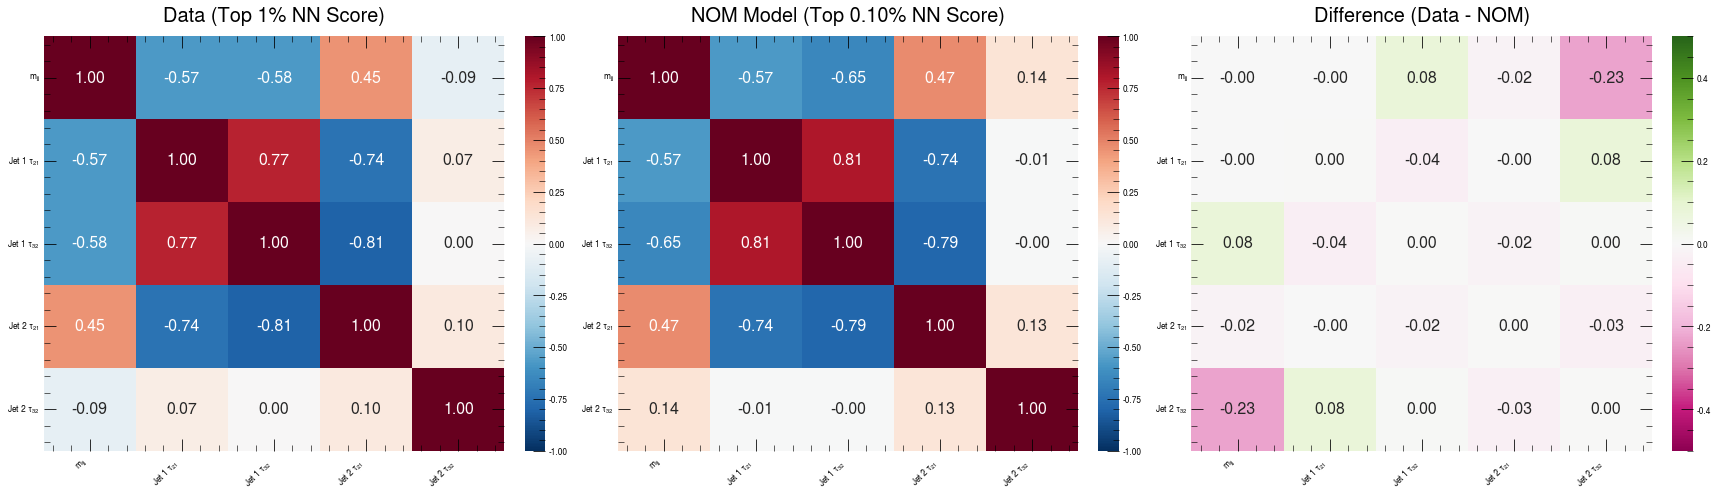

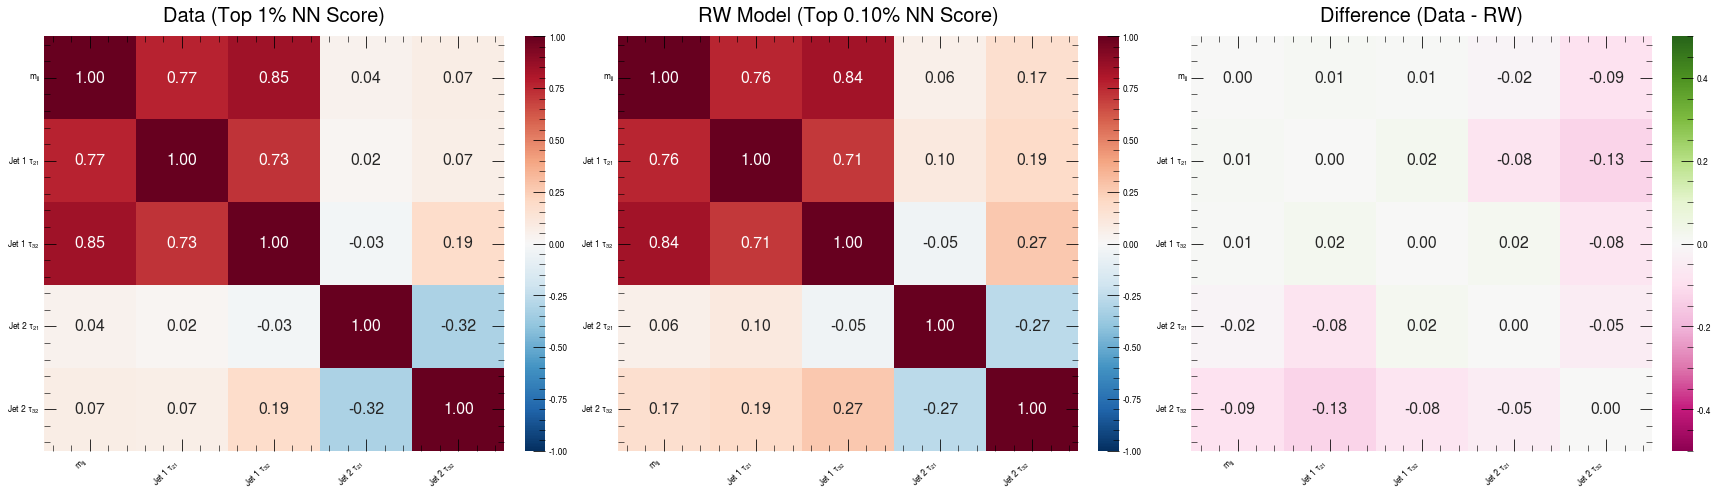

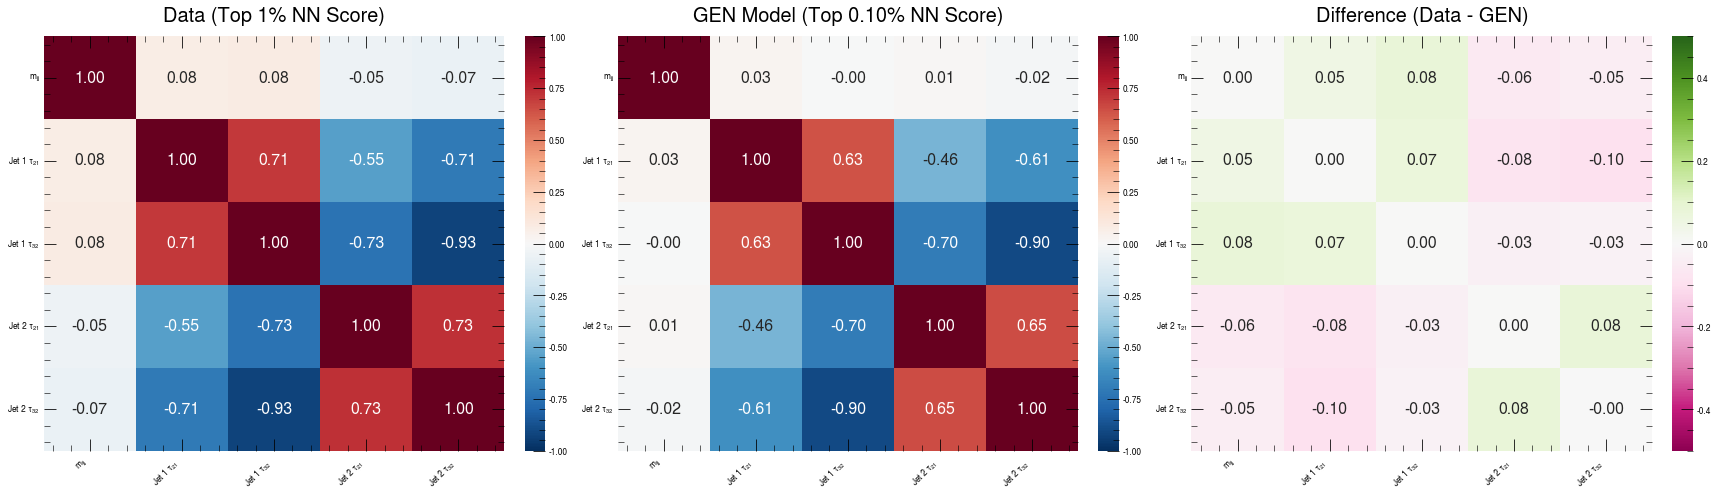

In [12]:
def get_weighted_correlation(df, features, weight_col):
    """Calculates the weighted Pearson correlation matrix."""
    # Extract arrays
    X = df[features].values
    w = df[weight_col].values
    w = np.abs(w)  # Ensure weights are non-negative
    # Calculate weighted covariance matrix (rowvar=False means columns are variables)
    cov_matrix = np.cov(X, rowvar=False, aweights=w)
    
    # Convert covariance to correlation matrix
    std_devs = np.sqrt(np.diag(cov_matrix))
    corr_matrix = cov_matrix / np.outer(std_devs, std_devs)
    
    return corr_matrix


features_list = ['mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32']

# For Data, assume weight is 1.0 for all events if unweighted
if 'weight' not in post_cut_data_nom.columns:
    df_data_unscaled['weight'] = 1.0
    post_cut_data_nom['weight'] = 1.0
    post_cut_data_rw['weight'] = 1.0
    post_cut_data_gen['weight'] = 1.0

corr_data_nom = get_weighted_correlation(post_cut_data_nom, features_list, 'weight')
corr_data_rw = get_weighted_correlation(post_cut_data_rw, features_list, 'weight')
corr_data_gen = get_weighted_correlation(post_cut_data_gen, features_list, 'weight')
corr_nom = get_weighted_correlation(post_cut_nom, features_list, 'final_weight')
corr_gen = get_weighted_correlation(post_cut_gen, features_list, 'total_weight')
corr_rw = get_weighted_correlation(post_cut_rw, features_list, 'rw_mediam_weights')

# The most important metric: where did the flowdf_data_unscaled fail?
corr_diff_nom = corr_data_nom - corr_nom
corr_diff_rw = corr_data_rw - corr_rw
corr_diff_gen = corr_data_gen - corr_gen


plot_corr_diff(corr_data_nom, corr_nom, corr_diff_nom, bkg_type="NOM", bkg_eff=bkg_eff)
plot_corr_diff(corr_data_rw, corr_rw, corr_diff_rw, bkg_type="RW", bkg_eff=bkg_eff)
plot_corr_diff(corr_data_gen, corr_gen, corr_diff_gen, bkg_type="GEN", bkg_eff=bkg_eff)

# Full Uncut correlations
corr_data = get_weighted_correlation(df_data_unscaled, features_list, 'weight')
corr_nom = get_weighted_correlation(df_mc_rw_unscaled, features_list, 'final_weight')
corr_rw = get_weighted_correlation(df_mc_rw_unscaled, features_list, 'rw_mediam_weights')
corr_gen = get_weighted_correlation(df_mc_gen_unscaled, features_list, 'total_weight')

corr_diff_nom_full = corr_data - corr_nom
corr_diff_rw_full = corr_data - corr_rw
corr_diff_gen_full = corr_data - corr_gen

# plot_corr_diff(corr_data, corr_nom, corr_diff_nom_full, bkg_type="NOM", bkg_eff=1.0)
# plot_corr_diff(corr_data, corr_rw, corr_diff_rw_full, bkg_type="RW", bkg_eff=1.0)
# plot_corr_diff(corr_data, corr_gen, corr_diff_gen_full, bkg_type="GEN", bkg_eff=1.0)

GEN Background modelling has some issues in generating the $\tau_{21}$ and $\tau_{32}$ variables. Therefore only RW Background modelling will be used for the background only hypothesis

### NULL HYPOTHESIS TESTING

##### 1. Kinematic Binning Strategy

To maximize sensitivity to narrow resonances while avoiding the "empty bin" pathology in high-mass $\chi^2$ testing, we use a dynamically scaled variable binning array. The bin widths are locked to the approximate Jet Energy Resolution (JER) of the detector, which scales at roughly 5% to 10% of $m_{jj}$.

- **400 - 1000 GeV**:  50 GeV bin width
- **1000 - 2000 GeV**: 100 GeV bin width
- **2000 - 4200 GeV**: 200 GeV bin width

Analytic advantage: This ensures that any localized particle resonance will naturally span roughly 2 to 3 bins, perfectly aligning with pyBumpHunter's dynamic window sweep (which tests widths from 2 to 15 bins).

##### 2. Systematic Uncertainties

The crux of a model-independent search lies in the robustness of its systematic envelope. We implement both weight-based normalizations and kinematic shape shifts.

| Systematic Source | Type | Parameterized Value(s) | Description |
| :--- | :--- | :--- | :--- |
| **Luminosity** | Normalization | Flat 5% | Standard detector luminosity measurement uncertainty ($\Delta B = 0.05 \times B_{nom}$). |
| **MC Statistical** | Uncorrelated Bin | $\sum w^2$ | The sum of squared MC weights per bin, capturing the limited statistics of the simulated sample. |
| **ML Epistemic** | Shape & Norm | 10 Ensembles | Standard deviation across 10 independent ML reweighting ensembles to capture neural network initialization and training variance. |
| **ML Non-Closure** | Normalization | Flat 5% | Derived from the Control Region (CR) where the ML classifier achieves an AUC $\approx 0.5$, proving the model does not artificially sculpt the mass distribution. |
| **Jet Energy Scale (JES)** | Kinematic Shape | 3% to 15% | Shifts the $m_{jj}$ kinematics directly. The uncertainty fraction scales linearly from 3% at 400 GeV up to 15% at 4000 GeV (capped at 15%). Events are physically shifted via $m_{jj} \times (1 \pm f_{JES})$ and re-binned. |
| **PDF Variations** | Weight Shape | 100 Variations | Theoretical uncertainties on Parton Distribution Functions. Evaluated using the standard deviation across 100 event-weight replicas. (Fallback envelope: linear scale from 5% at 400 GeV to 20% at 3600 GeV). |

##### 3. Statistical Framework (Null Hypothesis Testing)

Because we do not have a specific signal template, we cannot use a standard Profile Likelihood Ratio (like `pyhf` or `RooStats`). Instead, we rely on modified frequentist statistics tailored for bump hunts.

- **Local Significance**

For a localized window spanning from $m_{start}$ to $m_{end}$, the local significance $Z_{local}$ is approximated using the total integrated counts in that window:

$$Z_{local} = \frac{N_{obs} - B_{nom}}{\sqrt{B_{nom} + \sigma_{stat}^2 + \sum \sigma_{sys}^2}}$$

We treat the systematics (JES, ML closure, Lumi, PDFs) as fully correlated across the bins *within* the specific candidate window, meaning their standard deviations are summed linearly before being squared into the total variance.

- **Global Significance & The Look-Elsewhere Effect (LEE)**

Scanning a vast mass range (400 to 4200 GeV) introduces a massive multiple-testing penalty. We account for this using the **Gross & Vitells asymptotic approximation**. 

We calculate the effective number of independent search regions ($\mathcal{N}_{eff}$) by dividing the total mass range by the candidate window's width. The Trial Factor ($TF$) is then applied to the local p-value:

$$TF = 1 + \sqrt{2\pi} \cdot \mathcal{N}_{eff} \cdot Z_{local}$$
$$p_{global} = \min(p_{local} \times TF, 1.0)$$

- **Background Model Goodness-of-Fit**

To validate the overall ML background model, we compute a global Covariance Matrix ($\Sigma$) encompassing all statistical and systematic uncertainties across all bins. We invert this matrix (using pseudo-inverse to handle degenerate ranks from 100% correlated systematics like Luminosity) and calculate the Mahalanobis distance ($\chi^2$):

$$\chi^2 = (N - B_{nom})^T \Sigma^{-1} (N - B_{nom})$$

In [13]:
df_null_hypothesis = {}

mjj_bins = np.concatenate([
    np.arange(400, 1000, 50), 
    np.arange(1000, 2000, 100), 
    np.arange(2000, 4200, 200)
])
n_bins = len(mjj_bins) - 1

# Extract columns to numpy arrays for speed
mjj_data = post_cut_data_rw['mjj'].values

mjj_mc = post_cut_rw['mjj'].values
w_rw = post_cut_rw['rw_mediam_weights'].values
w_base = post_cut_rw['final_weight'].values # Base weight before ML ensemble variations

# Calculate Nominal Histograms
N, _ = np.histogram(mjj_data, bins=mjj_bins)
B, _ = np.histogram(mjj_mc, bins=mjj_bins, weights=w_rw)

# =====================================================================
# 2. STATISTICAL & ML SYSTEMATICS (WEIGHT-BASED, UNCORRELATED SHIFTS)
# =====================================================================
# A. MC Statistical Variance
var_stat = np.histogram(mjj_mc, bins=mjj_bins, weights=w_rw**2)[0]

# B. ML Epistemic Spread & Non-Closure
ensemble_yields = np.zeros((10, n_bins))
for i in range(10):
    w_ens = w_base * post_cut_rw[f'reweight_weights_ens{i}'].values
    ensemble_yields[i, :], _ = np.histogram(mjj_mc, bins=mjj_bins, weights=w_ens)

ensemble_std = np.std(ensemble_yields, axis=0)

# Closure error derived from ML model AUC ~ 0.5 in the Control Region
closure_err = 0.05 * B
std_ml_sys = np.sqrt(ensemble_std**2 + closure_err**2)

# =====================================================================
# 3. EXPERIMENTAL SYSTEMATICS (KINEMATIC SHAPE VARIATIONS)
# =====================================================================
# A. Luminosity (Flat 5%)
std_lumi_sys = 0.05 * B

# B. JES Shape (Kinematic Shift)
# 3% at 400GeV, 15% at 4000GeV
jes_fraction = 0.03 + (0.15 - 0.03) * ((mjj_mc - 400.0) / (4000.0 - 400.0))
jes_fraction = np.clip(jes_fraction, 0.03, 0.15) 

mjj_jes_up = mjj_mc * (1 + jes_fraction)
mjj_jes_down = mjj_mc * (1 - jes_fraction)

B_jes_up, _ = np.histogram(mjj_jes_up, bins=mjj_bins, weights=w_rw)
B_jes_down, _ = np.histogram(mjj_jes_down, bins=mjj_bins, weights=w_rw)

# =====================================================================
# 4. THEORETICAL SYSTEMATICS (PDF EVENT WEIGHT VARIATIONS)
# =====================================================================
n_pdf_vars = 100
pdf_yields = np.zeros((n_pdf_vars, n_bins))

for p in range(n_pdf_vars):
    if f'pdf_weight_{p}' in post_cut_rw.columns:
        w_pdf = w_rw * post_cut_rw[f'pdf_weight_{p}'].values
        pdf_yields[p, :], _ = np.histogram(mjj_mc, bins=mjj_bins, weights=w_pdf)
    else:
        # Fallback envelope if PDF weights are missing
        theory_frac = 0.05 + (0.20 - 0.05) * ((mjj_bins[:-1] + mjj_bins[1:])/2.0 - 400) / 3600
        pdf_yields[p, :] = B * (1 + theory_frac * np.random.normal())

# =====================================================================
# 5. PYBUMPHUNTER SCAN (STATISTICAL WINDOW IDENTIFICATION)
# =====================================================================
hunter = BH.BumpHunter1D(
    rang=[400, 4000],      
    width_min=2,           
    width_max=15,          
    width_step=1,          
    scan_step=1,           
    npe=10000,             
    nworker=4,             
    seed=42,               
    use_sideband=False     
)

print("Running pyBumpHunter scan (Stat-only to dynamically locate the candidate window)...")
# Note: Ran blindly to systematics to identify the geometric region of peak statistical deviation. 
# Systematics are evaluated explicitly on the resulting window in Step 6.
hunter.bump_scan(data=N, bkg=B, is_hist=True)

# =====================================================================
# 6. RIGOROUS WINDOW Z-SCORE EVALUATION (WITH SYSTEMATICS)
# =====================================================================
print("\n--- Final Null Hypothesis Test ---")
bump_results = {}

if hasattr(hunter, 'min_loc_ar') and len(hunter.min_loc_ar) > 0:
    start_idx = hunter.min_loc_ar[0]
    end_idx = hunter.min_loc_ar[1] + 1  # Exclusive index for array slicing
    
    # 1. Total Yields in the Window
    obs_data = np.sum(N[start_idx:end_idx])
    bkg_nom  = np.sum(B[start_idx:end_idx])
    
    # 2. Window Statistical Variance
    var_stat_win = np.sum(var_stat[start_idx:end_idx])
    
    # 3. Window Systematic Variance (Correlated Sums)
    var_ml_win = np.sum(std_ml_sys[start_idx:end_idx])**2
    var_lumi_win = np.sum(std_lumi_sys[start_idx:end_idx])**2
    
    # JES Shape: Integrate the shifted templates over the window, find diff to nominal
    bkg_jes_up   = np.sum(B_jes_up[start_idx:end_idx])
    bkg_jes_down = np.sum(B_jes_down[start_idx:end_idx])
    var_jes_win  = max(abs(bkg_jes_up - bkg_nom), abs(bkg_jes_down - bkg_nom))**2
    
    # PDF Shape: Std deviation of the integrated window yield across variations
    pdf_window_yields = np.sum(pdf_yields[:, start_idx:end_idx], axis=1)
    var_pdf_win = np.std(pdf_window_yields)**2
    
    # 4. Total Variance Calculation
    # Note: For model-independent searches without a signal template, we approximate 
    # the total uncertainty as the quadrature sum of stat and systematic variances.
    total_variance = (
        bkg_nom +        # Data Poisson variance approx (B)
        var_stat_win +   # MC Stat variance
        var_ml_win +     # ML Epistemic + Non-Closure
        var_lumi_win +   # Luminosity
        var_jes_win +    # JES Shape
        var_pdf_win      # PDF Weight Shape
    )
    
    total_std = np.sqrt(total_variance)
    sys_sig = (obs_data - bkg_nom) / total_std if total_variance > 0 else 0.0
    
    # =================================================================
    # 5. GROSS & VITELLS ASYMPTOTIC LOOK-ELSEWHERE EFFECT (LEE)
    # =================================================================
    # Corrected Trial Factor logic: 1 + sqrt(2pi) * N_eff * Z_fix
    
    Z_fix = sys_sig
    sys_local_pval = norm.sf(Z_fix)
    
    # 1. Estimate N_eff (Effective number of independent search regions)
    mass_range_total = mjj_bins[-1] - mjj_bins[0]
    window_mass_width = mjj_bins[end_idx-1] - mjj_bins[start_idx]
    
    if window_mass_width > 0:
        N_eff = mass_range_total / window_mass_width
    else:
        N_eff = 1.0

    # 2. Calculate the Gross & Vitells Trial Factor 
    if Z_fix > 0:
        lee_trial_factor = 1.0 + np.sqrt(2.0 * np.pi) * N_eff * Z_fix
    else:
        lee_trial_factor = 1.0
        
    # 3. Apply the Trial Factor to the systematic-inclusive local p-value
    sys_global_pval = min(sys_local_pval * lee_trial_factor, 1.0)
    
    # 4. Convert back to Global Significance
    sys_global_sig = norm.isf(sys_global_pval) if sys_global_pval < 0.5 else 0.0

    bump_results = {
        "found_bump": True,
        "indices": (start_idx, end_idx),
        "mass_range": (mjj_bins[start_idx], mjj_bins[end_idx-1]),
        "yields": {"obs_data": obs_data, "bkg_nom": bkg_nom},
        "variances_in_window": {
            "stat": var_stat_win,
            "ml": var_ml_win,
            "lumi": var_lumi_win,
            "jes": var_jes_win,
            "pdf": var_pdf_win,
            "total_variance": total_variance,
            "total_std": total_std
        },
        "significance": {
            "local_Z": Z_fix,
            "local_p": sys_local_pval,
            "N_eff": N_eff,
            "trial_factor": lee_trial_factor,
            "global_p": sys_global_pval,
            "global_Z": sys_global_sig
        }
    }

    # =================================================================
    # OUTPUT REPORT
    # =================================================================
    print(f"Candidate window:         {mjj_bins[start_idx]:.1f} - {mjj_bins[end_idx-1]:.1f} GeV")
    print(f"Data Yield:               {obs_data:.0f}")
    print(f"Background Yield:         {bkg_nom:.2f} ± {total_std:.2f} (Total Stat+Sys)")
    print(f"\n--- Significance Evaluation ---")
    print(f"Local Test Statistic Z:    {Z_fix:.2f} sigma")
    print(f"Effective Regions (N):     {N_eff:.1f}")
    print(f"Gross & Vitells Trial #:  ~{lee_trial_factor:.1f}")
    print(f"Final Global P-value:      {sys_global_pval:.5e}")
    print(f"Final Global Significance: {sys_global_sig:.2f} sigma")
    
    if sys_global_sig < 2.0:
        print("\nCONCLUSION: Fail to reject H0. Anomaly absorbed by Systematics and/or LEE.")
    else:
        print("\nCONCLUSION: Reject H0. The anomaly SURVIVES! Potential Discovery.")
else:
    bump_results = {"found_bump": False}
    print("No significant bumps found. Fail to reject H0.")


# =====================================================================
# 8. COVARIANCE MATRIX & CHI-SQUARE TEST (GLOBAL GOODNESS-OF-FIT)
# =====================================================================
# Evaluates the global model consistency (not designed for extracting narrow resonances)
print("\n--- Global Covariance Chi-Square Test (Goodness-of-Fit) ---")

n_bins = len(B)

cov_stat = np.diag(B + var_stat)

delta_lumi = 0.05 * B
cov_lumi = np.outer(delta_lumi, delta_lumi)

cov_ml_ens = np.cov(ensemble_yields, rowvar=False, bias=True)
delta_closure = 0.05 * B
cov_ml_closure = np.outer(delta_closure, delta_closure)
cov_ml = cov_ml_ens + cov_ml_closure

delta_jes = B_jes_up - B
cov_jes = np.outer(delta_jes, delta_jes)

cov_pdf = np.cov(pdf_yields, rowvar=False, bias=True)

cov_matrix = cov_stat + cov_lumi + cov_ml + cov_jes + cov_pdf
cov_matrix_inv = np.linalg.pinv(cov_matrix)

residuals = N - B
chi2_stat = residuals.T @ cov_matrix_inv @ residuals

dof = n_bins
global_p_val = chi2.sf(chi2_stat, dof)

if global_p_val > 0:
    global_z = norm.isf(global_p_val)
else:
    global_z = float('inf')

print(f"Chi-Square Statistic: {chi2_stat:.2f}")
print(f"Degrees of Freedom:   {dof}")
print(f"Global p-value:       {global_p_val:.4e}")
print(f"Global Z-score:       {global_z:.2f} sigma")

if global_z < 3.0:
    print("\nCONCLUSION: Fail to reject H0. The global background model fits the data.")
else:
    print("\nCONCLUSION: Reject H0. Significant global deviation from the background model.")

Running pyBumpHunter scan (Stat-only to dynamically locate the candidate window)...
Generating histograms
14 values of width will be tested
SCAN
Global p-value : 0.0000  (0 / 10000)
Significance > 3.71902 (lower limit)


--- Final Null Hypothesis Test ---
Candidate window:         400.0 - 450.0 GeV
Data Yield:               32
Background Yield:         17.69 ± 6.59 (Total Stat+Sys)

--- Significance Evaluation ---
Local Test Statistic Z:    2.17 sigma
Effective Regions (N):     72.0
Gross & Vitells Trial #:  ~392.7
Final Global P-value:      1.00000e+00
Final Global Significance: 0.00 sigma

CONCLUSION: Fail to reject H0. Anomaly absorbed by Systematics and/or LEE.

--- Global Covariance Chi-Square Test (Goodness-of-Fit) ---
Chi-Square Statistic: 75.42
Degrees of Freedom:   32
Global p-value:       2.3067e-05
Global Z-score:       4.07 sigma

CONCLUSION: Reject H0. Significant global deviation from the background model.


In [14]:
df_null_hypothesis = {
    "metadata": {
        "mjj_bins": mjj_bins,
        "n_bins": n_bins
    },
    "histograms": {
        "data_N": N,
        "bkg_nom_B": B
    },
    "systematic_arrays": {
        "var_stat": var_stat,
        "std_ml_sys": std_ml_sys,
        "std_lumi_sys": std_lumi_sys,
        "B_jes_up": B_jes_up,
        "B_jes_down": B_jes_down,
        "ensemble_yields": ensemble_yields,
        "pdf_yields": pdf_yields
    },
    "bump_hunter_results": bump_results,
    "covariance_matrices": {
        "cov_stat": cov_stat,
        "cov_lumi": cov_lumi,
        "cov_ml": cov_ml,
        "cov_jes": cov_jes,
        "cov_pdf": cov_pdf,
        "cov_total": cov_matrix,
        "cov_total_inv": cov_matrix_inv
    },
    "global_fit_results": {
        "chi2_stat": chi2_stat,
        "dof": dof,
        "global_p_val": global_p_val,
        "global_z": global_z,
        "residuals": residuals
    }
}

# Save the dictionary to disk for replicability
with open(f"Results/df_null_hypothesis_results_{bkg_eff}.pkl", "wb") as f:
    pickle.dump(df_null_hypothesis, f)

print("\nSaved `df_null_hypothesis_results.pkl` to disk. Ready for replication. Background rejection used: {:.2f}%".format(bkg_eff * 100))


Saved `df_null_hypothesis_results.pkl` to disk. Ready for replication. Background rejection used: 0.10%


/tmp/ipykernel_337270/3645490553.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


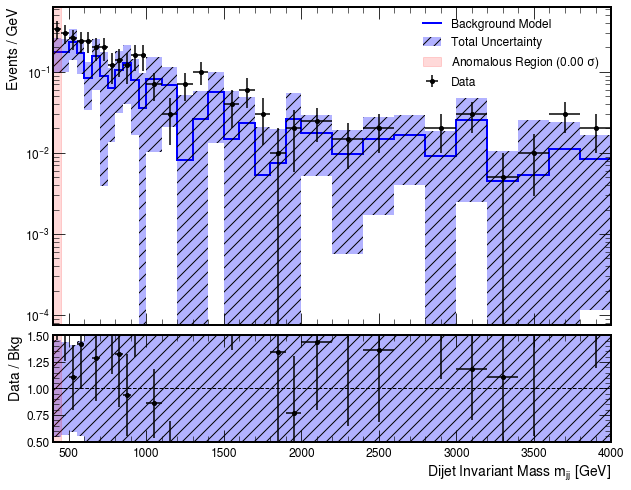

In [15]:
# =====================================================================
# 1. PREPARE THE DATA (Convert to Events / GeV)
# =====================================================================
# Calculate bin widths and centers
bin_widths = np.diff(mjj_bins)
bin_centers = mjj_bins[:-1] + bin_widths / 2.0

# Extract per-bin total systematic error from the diagonal of the Covariance Matrix (from Step 8)
# cov_matrix = cov_stat + cov_lumi + cov_ml + cov_jes + cov_pdf
err_bkg = np.sqrt(np.diag(cov_matrix))

# Convert everything to Events / GeV for plotting
plot_N = N / bin_widths
plot_N_err = np.sqrt(N) / bin_widths # Poisson statistical error on data

plot_B = B / bin_widths
plot_B_err = err_bkg / bin_widths

# =====================================================================
# 2. SET UP THE FIGURE WITH RATIO PANEL
# =====================================================================
fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)

# Main spectrum plot
ax_main = fig.add_subplot(gs[0])
# Ratio plot
ax_ratio = fig.add_subplot(gs[1], sharex=ax_main)

# =====================================================================
# 3. PLOT MAIN SPECTRUM
# =====================================================================
# Plot Background as a step line
ax_main.stairs(plot_B, mjj_bins, baseline=None, color='blue', linewidth=2, label='Background Model')

# Plot Background Error Band (Hatched fill)
# To use fill_between with steps, we need to duplicate bin edges and values
mjj_edges_dup = np.repeat(mjj_bins, 2)[1:-1]
plot_B_dup = np.repeat(plot_B, 2)
plot_B_err_dup = np.repeat(plot_B_err, 2)

ax_main.fill_between(mjj_edges_dup, 
                     plot_B_dup - plot_B_err_dup, 
                     plot_B_dup + plot_B_err_dup, 
                     step='mid', facecolor='blue', alpha=0.3, hatch='//', label='Total Uncertainty')

# Plot Data as points with error bars
ax_main.errorbar(bin_centers, plot_N, yerr=plot_N_err, xerr=bin_widths/2, 
                 fmt='o', color='black', label='Data', markersize=4, capsize=0)

# Highlight Candidate Window (400 - 1500 GeV)
ax_main.axvspan(bump_results["mass_range"][0], bump_results["mass_range"][1], color='red', alpha=0.15, label=f'Anomalous Region ({bump_results["significance"]["global_Z"]:.2f} $\sigma$)')

# Formatting Main Panel
ax_main.set_yscale('log')
ax_main.set_ylabel('Events / GeV', fontsize=14)
ax_main.tick_params(axis='both', which='major', labelsize=12)
ax_main.legend(loc='upper right', fontsize=12, frameon=False)
ax_main.set_xlim(mjj_bins[0], mjj_bins[-1])

# Hide x-axis labels on the main plot to make it flush with the ratio plot
plt.setp(ax_main.get_xticklabels(), visible=False)

# =====================================================================
# 4. PLOT RATIO PANEL (Data / Bkg)
# =====================================================================
# Calculate ratio and errors
ratio = np.zeros_like(plot_N)
ratio_err = np.zeros_like(plot_N)

# Avoid division by zero
valid = plot_B > 0
ratio[valid] = plot_N[valid] / plot_B[valid]
ratio_err[valid] = plot_N_err[valid] / plot_B[valid]

# Background error band in the ratio (centered at 1.0)
rel_bkg_err = np.zeros_like(plot_B_err)
rel_bkg_err[valid] = plot_B_err[valid] / plot_B[valid]
rel_bkg_err_dup = np.repeat(rel_bkg_err, 2)

# Plot ratio error band
ax_ratio.fill_between(mjj_edges_dup, 
                      1.0 - rel_bkg_err_dup, 
                      1.0 + rel_bkg_err_dup, 
                      facecolor='blue', alpha=0.3, hatch='//')

# Plot Data/Bkg points
ax_ratio.errorbar(bin_centers, ratio, yerr=ratio_err, xerr=bin_widths/2, 
                  fmt='o', color='black', markersize=4, capsize=0)

# Reference line at 1.0
ax_ratio.axhline(1.0, color='black', linestyle='--', linewidth=1)

# Highlight Candidate Window in Ratio
ax_ratio.axvspan(bump_results["mass_range"][0], bump_results["mass_range"][1], color='red', alpha=0.15)

# Formatting Ratio Panel
ax_ratio.set_xlabel('Dijet Invariant Mass $m_{jj}$ [GeV]', fontsize=14)
ax_ratio.set_ylabel('Data / Bkg', fontsize=14)
ax_ratio.set_ylim(0.5, 1.5) # Standard ratio limits for dijet searches
ax_ratio.set_yticks([0.5, 0.75, 1.0, 1.25, 1.5])
ax_ratio.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.savefig(f"Results/dijet_null_hypothesis_{bkg_eff}.pdf")
plt.show()

## Phase 2: BSM Signal

In [16]:
# h1_results = []

# for sig_id in SIGNAL_MODES:
#     df_sig = df_sig_def_unscaled[sig_id]
    
#     # --- 1. APPLY THE SIGNAL REGION CUT ---
#     # Apply the exact same 1% anomaly score threshold used for Data and Background
#     sig_sr = df_sig[df_sig['bsm_score_Reweight_Median'] > rw_threshold]
    
#     # --- 2. CALCULATE SIGNAL YIELDS & VARIANCE ---
#     # Bin the surviving signal events into the same mjj_bins
#     S_i, _ = np.histogram(sig_sr['mjj'].values, bins=mjj_bins, weights=sig_sr['final_weight'].values)
    
#     # Calculate the statistical variance of the signal (sum of squared weights)
#     var_sig_stat_i = np.histogram(sig_sr['mjj'].values, bins=mjj_bins, weights=sig_sr['final_weight'].values**2)[0]
    
#     # If the signal is entirely killed by the anomaly cut, record 0 and skip
#     if S_i.sum() <= 0:
#         h1_results.append({
#             "Model": sig_id, "Mass Window": "N/A", "Exp. B": 0, "Obs. Data": 0, 
#             "Data Excess": 0, "Signal (S)": 0, "Exp. Z": 0.0, "Pull (H1)": np.nan
#         })
#         continue
        
#     # --- 3. DYNAMICALLY DEFINE THE SIGNAL MASS WINDOW ---
#     # A resonance is narrow. We find the bins where the signal yield is at least 
#     # 5% of the peak signal bin to define the active signal window.
#     active_bins = np.where(S_i > 0.05 * np.max(S_i))[0]
#     start_idx = active_bins[0]
#     end_idx = active_bins[-1]
    
#     window_start_mass = mjj_bins[start_idx]
#     window_end_mass = mjj_bins[end_idx + 1]
    
#     # --- 4. EXTRACT YIELDS IN THE WINDOW ---
#     S_win = np.sum(S_i[start_idx : end_idx + 1])
#     B_win = np.sum(B[start_idx : end_idx + 1])
#     N_win = np.sum(N[start_idx : end_idx + 1])
    
#     # --- 5. EXTRACT & COMBINE VARIANCES IN THE WINDOW ---
#     # Background variances (using the logic fixed in the previous steps)
#     window_var_stat_bkg = np.sum(var_stat[start_idx : end_idx + 1])
#     window_std_sys_bkg = np.sum(np.sqrt(var_sys_total[start_idx : end_idx + 1]))
#     window_var_sys_bkg = window_std_sys_bkg**2  # Correlated squaring
    
#     window_var_bkg = window_var_stat_bkg + window_var_sys_bkg
    
#     # Signal statistical variance
#     window_var_sig = np.sum(var_sig_stat_i[start_idx : end_idx + 1])
    
#     # --- 6. CALCULATE HYPOTHESIS METRICS ---
#     # Expected Significance (Sensitivity): S / sqrt(B + Var_B)
#     Z_exp = S_win / np.sqrt(B_win + window_var_bkg) if (B_win + window_var_bkg) > 0 else 0
    
#     # H1 Pull: (Data - (B + S)) / sqrt(B + S + Var_B + Var_S)
#     # Note: B_win and S_win are included in the denominator as Poisson variance terms
#     total_variance_H1 = B_win + S_win + window_var_bkg + window_var_sig
#     pull_H1 = (N_win - (B_win + S_win)) / np.sqrt(total_variance_H1) if total_variance_H1 > 0 else 0
    
#     # Data excess for contextual comparison
#     excess_win = N_win - B_win
    
#     # Append to results
#     h1_results.append({
#         "Model": sig_id,
#         "Mass Window": f"{window_start_mass:.0f}-{window_end_mass:.0f}",
#         "Exp. B": B_win,
#         "Obs. Data": N_win,
#         "Data Excess": excess_win,
#         "Signal (S)": S_win,
#         "Exp. Z": Z_exp,
#         "Pull (H1)": pull_H1
#     })

# # --- 7. DISPLAY RESULTS ---
# df_h1 = pd.DataFrame(h1_results)
# print("\n--- Alternative Hypothesis (H1) Evaluation ---")
# print(df_h1.to_string(index=False, float_format=lambda x: f"{x:.2f}" if isinstance(x, float) else x))

In [ ]:
pyhf.set_backend("numpy")

print(f"\n--- Running pyhf Profile Likelihood Fits for BSM Models --- at Background Uncertainty {bkg_eff:.2%}")
# --- 1. PREPARE THE SYSTEMATICS ARRAYS ---
# We use the arrays we already built in the H0 step.
# pyhf requires strict avoidance of 0-background bins for stability.
valid_bins = B > 0

B_valid = B[valid_bins]
N_valid = N[valid_bins]
err_stat_valid = np.sqrt(var_stat[valid_bins])  # Absolute stat error
err_ml_valid = std_ml_sys[valid_bins]           # Absolute ML error

# For correlated shape systematics (histosys), pyhf needs the absolute yields of the Up/Down shifts
B_jes_up = B_jes_up[valid_bins]
B_jes_down = B_jes_down[valid_bins]
std_theory_sys = np.std(pdf_yields, axis=0)

B_theory_up = B_valid + std_theory_sys[valid_bins]
B_theory_down = np.clip(B_valid - std_theory_sys[valid_bins], a_min=1e-6, a_max=None)

# List to store our rigorous pyhf results
pyhf_results = []

print("--- Running pyhf Profile Likelihood Fits for BSM Models ---")

# --- 2. LOOP OVER SIGNALS & BUILD WORKSPACES ---
for sig_id in SIGNAL_MODES:
    df_sig = df_sig_def_unscaled[sig_id]
    
    
    sig_sr = df_sig[df_sig['bsm_score_Reweight_Median'] > rw_threshold]
    
    # Calculate Signal Yield
    S, _ = np.histogram(sig_sr['mjj'].values, bins=mjj_bins, weights=sig_sr['final_weight'].values)
    S_valid = S[valid_bins]
    
    # Skip models entirely killed by the anomaly cut
    if S_valid.sum() <= 1e-3:
        pyhf_results.append({
            "Model": sig_id, "Signal Yield": 0.0, 
            "Best-fit Mu": np.nan, "Observed CLs": np.nan, "Expected CLs": np.nan
        })
        continue


    # =====================================================================
    # NEW: DYNAMIC MU SCAN CALCULATION
    # =====================================================================
    # Approximate the background variance using a simple Poisson sqrt(B)
    approx_bkg_err = np.sqrt(B_valid.sum())
    
    # Estimate the mu needed to hit a ~2 sigma excess
    estimated_mu_limit = (2.0 * approx_bkg_err) / S_valid.sum()
    
    # Set the max scan range to 3 times the estimate to give pyhf plenty of room.
    # We clip it between 5.0 (for strong signals) and 200.0 (for impossibly weak signals).
    mu_max = float(np.clip(estimated_mu_limit * 3.0, a_min=5.0, a_max=None))
    
    # Create 51 points just within our custom, targeted range
    scan_mu = np.linspace(0.0, mu_max, 51)
    # =====================================================================


    # --- 3. CONSTRUCT THE PYHF WORKSPACE ---
    # This translates our arrays and uncertainties into a formal statistical model
    workspace_dict = {
        "channels": [
            {
                "name": "signal_region",
                "samples": [
                    {
                        "name": "background",
                        "data": B_valid.tolist(),
                        "modifiers": [
                            # 1. MC Statistical Error
                            {"name": "staterror", "type": "staterror", "data": err_stat_valid.tolist()},
                            # 2. Luminosity (5% normalization uncertainty)
                            {"name": "lumi", "type": "normsys", "data": {"hi": 1.05, "lo": 0.95}},
                            # 3. JES/JER (Correlated Shape uncertainty)
                            {"name": "jes_jer", "type": "histosys", "data": {"hi_data": B_jes_up.tolist(), "lo_data": B_jes_down.tolist()}},
                            # 4. Theory PDF/Scale (Correlated Shape uncertainty)
                            {"name": "theory", "type": "histosys", "data": {"hi_data": B_theory_up.tolist(), "lo_data": B_theory_down.tolist()}},
                            # 5. ML Epistemic Spread + Non-Closure (Uncorrelated bin-by-bin shape uncertainty)
                            {"name": "ml_systematics", "type": "shapesys", "data": err_ml_valid.tolist()}
                        ]
                    },
                    {
                        "name": "signal",
                        "data": S_valid.tolist(),
                        "modifiers": [
                            # The Parameter of Interest (POI)
                            {"name": "mu", "type": "normfactor", "data": None}
                        ]
                    }
                ]
            }
        ],
        "observations": [
            {"name": "signal_region", "data": N_valid.tolist()}
        ],
        "measurements": [
            {
                "name": "Measurement", 
                "config": {
                    "poi": "mu", 
                    "parameters": [
                        {
                            "name": "mu",
                            "bounds": [[0.0, float(mu_max * 1.2)]]
                        }
                    ]
                }
            }
        ],
        "version": "1.0.0"
    }
    
    # Build the model and data array (combining observations + auxiliary constraint data)
    workspace = pyhf.Workspace(workspace_dict)
    model = workspace.model()
    data = workspace.data(model)

    best_fit_pars = pyhf.infer.mle.fit(data, model)
    mu_hat = best_fit_pars[model.config.poi_index]

    
    obs_limit, exp_limits, details= pyhf.infer.intervals.upper_limits.upper_limit(
        data, 
        model, 
        scan_mu, 
        level=0.05, 
        return_results=True
    )
    
    try:
        # C. Safely extract ALL the expected limit bands
        if isinstance(exp_limits, (list, tuple, np.ndarray)) and len(exp_limits) >= 5:
            exp_m2  = float(np.asarray(exp_limits)[0]) # -2 sigma
            exp_m1  = float(np.asarray(exp_limits)[1]) # -1 sigma
            exp_med = float(np.asarray(exp_limits)[2]) # Median
            exp_p1  = float(np.asarray(exp_limits)[3]) # +1 sigma
            exp_p2  = float(np.asarray(exp_limits)[4]) # +2 sigma
        else:
            exp_m2 = exp_m1 = exp_med = exp_p1 = exp_p2 = np.nan
            
        # D. Safely extract the observed limit
        try:
            obs_limit = float(np.asarray(obs_limit))
        except (TypeError, ValueError):
            obs_limit = np.nan
        
        pyhf_results.append({
            "Model": sig_id,
            "Signal Yield": S_valid.sum(),
            "Best-fit Mu": mu_hat,
            "Obs_Limit": obs_limit,
            "Exp_m2": exp_m2,
            "Exp_m1": exp_m1,
            "Exp_med": exp_med,
            "Exp_p1": exp_p1,
            "Exp_p2": exp_p2
        })
    except Exception as e:
        print(f"Fit failed for {sig_id}: {e}")
        pyhf_results.append({
            "Model": sig_id, "Signal Yield": S_valid.sum(), 
            "Best-fit Mu": np.nan, "Obs_Limit": np.nan, "Exp_m2": np.nan, "Exp_m1": np.nan, "Exp_med": np.nan, "Exp_p1": np.nan, "Exp_p2": np.nan
        })

# --- 5. DISPLAY RESULTS ---
df_pyhf = pd.DataFrame(pyhf_results)
print("\n--- pyhf Profile Likelihood Results ---")
print(df_pyhf.to_string(index=False, float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else x))


--- Running pyhf Profile Likelihood Fits for BSM Models --- at Background Uncertainty 0.10%
--- Running pyhf Profile Likelihood Fits for BSM Models ---


In [ ]:
df_pyhf.to_csv(f"Results/df_alter_hypothesis_results_{bkg_eff}.csv", index=False)

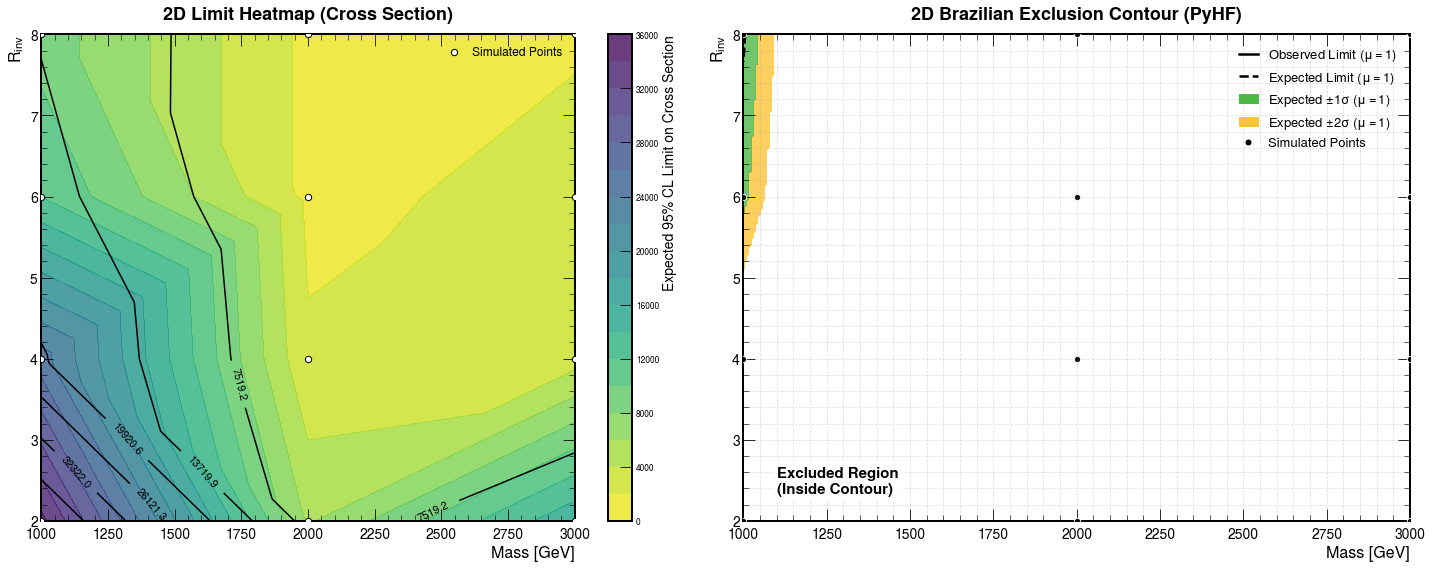

In [ ]:
def plot_2d_bsm_limits_corrected(df, 
                                 mass_col='Mass', 
                                 rinv_col='Rinv', 
                                 xs_col='XS',
                                 obs_col='Obs_Limit', 
                                 med_col='Exp_med',
                                 m1_col='Exp_m1', 
                                 p1_col='Exp_p1', 
                                 m2_col='Exp_m2', 
                                 p2_col='Exp_p2',
                                 exclusion_threshold=1.0,
                                 title_suffix="(PyHF)"):
    """
    Plots a 2D Heatmap (in Cross Section) and a 2D Brazilian Contour (in mu) side-by-side.
    """
    # Drop rows where limits or theoretical XS could not be found
    df_plot = df.dropna(subset=[med_col, obs_col, xs_col]).copy()
    
    x = df_plot[mass_col].values
    y = df_plot[rinv_col].values
    
    # Create the 2D Interpolation Grid (300x300 density)
    xi = np.linspace(x.min(), x.max(), 300)
    yi = np.linspace(y.min(), y.max(), 300)
    X, Y = np.meshgrid(xi, yi)
    
    # =====================================================================
    # INTERPOLATE FOR HEATMAP (CROSS SECTION)
    # =====================================================================
    # Multiply the mu limits by the theoretical cross section
    z_med_xs = df_plot[med_col].values * df_plot[xs_col].values
    z_obs_xs = df_plot[obs_col].values * df_plot[xs_col].values
    
    Z_med_XS = griddata((x, y), z_med_xs, (X, Y), method='linear')
    Z_obs_XS = griddata((x, y), z_obs_xs, (X, Y), method='linear')
    
    # =====================================================================
    # INTERPOLATE FOR BRAZILIAN CONTOUR (SIGNAL STRENGTH MU)
    # =====================================================================
    Z_obs = griddata((x, y), df_plot[obs_col].values, (X, Y), method='linear')
    Z_med = griddata((x, y), df_plot[med_col].values, (X, Y), method='linear')
    Z_m1  = griddata((x, y), df_plot[m1_col].values, (X, Y), method='linear')
    Z_p1  = griddata((x, y), df_plot[p1_col].values, (X, Y), method='linear')
    Z_m2  = griddata((x, y), df_plot[m2_col].values, (X, Y), method='linear')
    Z_p2  = griddata((x, y), df_plot[p2_col].values, (X, Y), method='linear')
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # =====================================================================
    # PLOT 1: 2D LIMIT HEATMAP (CROSS SECTION)
    # =====================================================================
    ax1 = axes[0]
    
    # Draw expected limit heatmap in XS
    cf1 = ax1.contourf(X, Y, Z_med_XS, cmap='viridis_r', levels=20, alpha=0.8)
    cbar = fig.colorbar(cf1, ax=ax1)
    cbar.set_label('Expected 95% CL Limit on Cross Section', fontsize=14)
    
    # Draw observed limit contours in XS
    try:
        if not np.isnan(Z_obs_XS).all():
            obs_levels = np.linspace(np.nanmin(Z_obs_XS), np.nanmax(Z_obs_XS), 8)
            cs1 = ax1.contour(X, Y, Z_obs_XS, colors='black', linestyles='solid', linewidths=1.5, levels=obs_levels)
            ax1.clabel(cs1, inline=True, fontsize=11, fmt='%1.1f')
    except Exception:
        pass
        
    ax1.scatter(x, y, color='white', edgecolor='black', s=40, zorder=5, label='Simulated Points')
    ax1.set_xlabel('Mass [GeV]', fontsize=16)
    ax1.set_ylabel(r'$R_{inv}$', fontsize=16)
    ax1.set_title(f'2D Limit Heatmap (Cross Section)', fontsize=18, fontweight='bold', pad=15)
    ax1.legend(loc='upper right', fontsize=12)
    ax1.tick_params(axis='both', labelsize=14)
    
    # =====================================================================
    # PLOT 2: 2D BRAZILIAN CONTOUR (SIGNAL STRENGTH MU)
    # =====================================================================
    ax2 = axes[1]
    
    band_grid = np.zeros_like(X)
    band_grid[(Z_m2 <= exclusion_threshold) & (Z_m1 > exclusion_threshold)] = 1
    band_grid[(Z_p1 <= exclusion_threshold) & (Z_p2 > exclusion_threshold)] = 1
    band_grid[(Z_m1 <= exclusion_threshold) & (Z_p1 > exclusion_threshold)] = 2
    
    ax2.contourf(X, Y, band_grid, levels=[0.5, 1.5, 2.5], colors=['#FDC536', '#4DB848'], alpha=0.8)
    
    try:
        ax2.contour(X, Y, Z_med, levels=[exclusion_threshold], colors='black', linestyles='dashed', linewidths=2.5)
    except ValueError:
        pass 
        
    try:
        ax2.contour(X, Y, Z_obs, levels=[exclusion_threshold], colors='black', linestyles='solid', linewidths=2.5)
    except ValueError:
        pass 
        
    ax2.scatter(x, y, color='black', s=40, edgecolor='white', alpha=0.9, zorder=5, label='Simulated Points')
    
    yellow_patch = mpatches.Patch(color='#FDC536', label=r'Expected $\pm 2\sigma$ ($\mu=1$)')
    green_patch  = mpatches.Patch(color='#4DB848', label=r'Expected $\pm 1\sigma$ ($\mu=1$)')
    exp_line     = mlines.Line2D([], [], color='black', linestyle='dashed', linewidth=2.5, label='Expected Limit ($\mu=1$)')
    obs_line     = mlines.Line2D([], [], color='black', linestyle='solid', linewidth=2.5, label='Observed Limit ($\mu=1$)')
    points       = mlines.Line2D([], [], color='black', marker='o', markeredgecolor='white', linestyle='None', markersize=7, label='Simulated Points')
    
    ax2.legend(handles=[obs_line, exp_line, green_patch, yellow_patch, points], loc='upper right', fontsize=13, framealpha=0.95)
    
    ax2.set_xlabel('Mass [GeV]', fontsize=16)
    ax2.set_ylabel(r'$R_{inv}$', fontsize=16)
    ax2.set_title(f'2D Brazilian Exclusion Contour {title_suffix}', fontsize=18, fontweight='bold', pad=15)
    
    ax2.text(0.05, 0.05, "Excluded Region\n(Inside Contour)", transform=ax2.transAxes, 
            fontsize=15, fontweight='bold', color='black', verticalalignment='bottom', 
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=5))
            
    ax2.tick_params(axis='both', labelsize=14)
    ax2.grid(True, which='both', linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    plt.savefig(f"Results/2D_BSM_Limits_{bkg_eff}.pdf")
    plt.show()


df_pyhf = pd.read_csv(f'Results/df_alter_hypothesis_results_{bkg_eff}.csv')
df_pyhf[['Mass', 'Rinv']] = df_pyhf['Model'].str.split('_', expand=True).astype(float)
df_merged = pd.merge(df_pyhf, DF_META, on=['Mass', 'Rinv'])
plot_2d_bsm_limits_corrected(df_merged)